# MLSP 2013 Bird Classification Challenge
## Multi-Label Audio Classification

**Opdracht**: Classificeer welke van de 19 vogelsoorten aanwezig zijn in 10-seconden audio-opnames.

**Kernpunten:**
- 19 verschillende vogelsoorten
- Multi-label classificatie (meerdere vogels per opname mogelijk)
- Audio data: 10-sec WAV files, 16kHz, mono
- Output: Probability (0-1) voor elke soort per test opname

---
## Stap 1: Libraries Importeren

In [1]:
# Data verwerking
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Audio verwerking
import librosa
import librosa.display
import soundfile as sf

# Visualisatie
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.multioutput import MultiOutputClassifier

# Deep Learning (avoor de nn)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Overige utilities
import warnings
warnings.filterwarnings('ignore')

# Plotting stijl
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Alle libraries goed ingeladen!")
print(f"NumPy versie: {np.__version__}")
print(f"Pandas versie: {pd.__version__}")
print(f"Librosa versie: {librosa.__version__}")

Alle libraries goed ingeladen!
NumPy versie: 2.1.3
Pandas versie: 2.3.2
Librosa versie: 0.11.0


## Stap 2: Data Paths en Configuratie

In [15]:
# Data directories
BASE_DIR = Path(r"c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025")
ESSENTIAL_DATA = BASE_DIR / "essential_data"
SUPPLEMENTAL_DATA = BASE_DIR / "supplemental_data"

# Belangrijke files
SPECIES_LIST = ESSENTIAL_DATA / "species_list.txt"
CV_FOLDS = ESSENTIAL_DATA / "CVfolds_2.txt"
REC_ID_TO_FILE = ESSENTIAL_DATA / "rec_id2filename.txt"
LABELS_FILE = ESSENTIAL_DATA / "rec_labels_test_hidden.txt"
SAMPLE_SUBMISSION = ESSENTIAL_DATA / "sample_submission.csv"

# Audio files
SRC_WAVS = ESSENTIAL_DATA / "src_wavs"

# Spectrograms
SPECTROGRAMS = BASE_DIR / "spectrograms"
FILTERED_SPECTROGRAMS = SUPPLEMENTAL_DATA / "filtered_spectrograms"

# Check of alles bestaat
print("Checking data directories...")
for path, name in [
    (ESSENTIAL_DATA, "Essential Data"),
    (SUPPLEMENTAL_DATA, "Supplemental Data"),
    (SRC_WAVS, "WAV Files"),
    (SPECTROGRAMS, "Spectrograms")
]:
    exists = "Bestaat" if path.exists() else "ERROR, Bestaad niet!"
    print(f"{exists} {name}: {path}")

print(f"\n Aantal WAV bestanden: {len(list(SRC_WAVS.glob('*.wav'))) if SRC_WAVS.exists() else 0}")
print(f" Aantal Spectrograms: {len(list(SPECTROGRAMS.glob('*.bmp'))) if SPECTROGRAMS.exists() else 0}")

Checking data directories...
Bestaat Essential Data: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data
Bestaat Supplemental Data: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\supplemental_data
Bestaat WAV Files: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data\src_wavs
Bestaat Spectrograms: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\spectrograms

 Aantal WAV bestanden: 645
 Aantal Spectrograms: 0


## Stap 3: Data Inladen en Verkennen

In [20]:
# 1. Species lijst inladen
species_df = pd.read_csv(SPECIES_LIST)
print("Vogelsoorten in de dataset:")
print(species_df)
print(f"\nTotaal aantal soorten: {len(species_df)}")

Vogelsoorten in de dataset:
    class_id  code                    species
0          0  BRCR              Brown Creeper
1          1  PAWR               Pacific Wren
2          2  PSFL   Pacific-slope Flycatcher
3          3  RBNU      Red-breasted Nuthatch
4          4  DEJU            Dark-eyed Junco
5          5  OSFL     Olive-sided Flycatcher
6          6  HETH              Hermit Thrush
7          7  CBCH  Chestnut-backed Chickadee
8          8  VATH              Varied Thrush
9          9  HEWA             Hermit Warbler
10        10  SWTH          Swainson's Thrush
11        11  HAFL       Hammond's Flycatcher
12        12  WETA            Western Tanager
13        13  BHGB      Black-headed Grosbeak
14        14  GCKI     Golden Crowned Kinglet
15        15  WAVI             Warbling Vireo
16        16  MGWA     MacGillivray's Warbler
17        17  STJA              Stellar's Jay
18        18  CONI           Common Nighthawk

Totaal aantal soorten: 19


In [ ]:
# 2. CV Folds inladen (training/test split)
cv_folds = pd.read_csv(CV_FOLDS)  # Heeft al een header, waarom heeft deze al een header? 
print("Training/Test split:\n")
print(cv_folds['fold'].value_counts().sort_index())
print(f"\n0 = Training set, 1 = Test set")
print(f"Training: {(cv_folds['fold']==0).sum()} opnames")
print(f"Test: {(cv_folds['fold']==1).sum()} opnames")
print(f"\nData types:")
print(cv_folds.dtypes)

Training/Test split:

fold
0    322
1    323
Name: count, dtype: int64

0 = Training set, 1 = Test set
Training: 322 opnames
Test: 323 opnames

Data types:
rec_id    int64
fold      int64
dtype: object


In [24]:
# 3. Labels inladen
# We moeten dit bestand parsen want het formaat is: rec_id,[labels]
labels_data = []
with open(LABELS_FILE, 'r') as f:
    next(f)  # Skip header
    for line in f:
        line = line.strip()
        if ',' in line:
            parts = line.split(',')
            rec_id = int(parts[0])
            # Labels zijn alle getallen na de eerste komma
            labels = [int(x) for x in parts[1:] if x.isdigit()]
            labels_data.append({'rec_id': rec_id, 'labels': labels})
        else:
            # Geen labels (lege regel of alleen rec_id)
            if line.isdigit():
                labels_data.append({'rec_id': int(line), 'labels': []})

labels_df = pd.DataFrame(labels_data)
print("Labels dataset:")
print(labels_df.head(20))
print(f"\nTotaal aantal opnames: {len(labels_df)}")

Labels dataset:
    rec_id    labels
0        0        []
1        1        []
2        2  [11, 12]
3        3        []
4        4        []
5        5      [10]
6        6        []
7        7        []
8        8        []
9        9        []
10      10        []
11      11        []
12      12        []
13      13  [15, 17]
14      14        []
15      15        []
16      16        []
17      17        []
18      18       [1]
19      19       [2]

Totaal aantal opnames: 645


In [77]:
# 4. Alles combineren in één DataFrame
df = labels_df.merge(cv_folds, on='rec_id')

# Identificeer training en test
df['is_train'] = df['fold'] == 0
df['is_test'] = df['fold'] == 1

# Voor training data: bepaal het aantal labels per opname
df['num_labels'] = df['labels'].apply(len)

print("Dataset Overview:")
print(df.head)
print(f"\n{'='*60}")
print("Label statistieken (alleen training data met labels):")
train_with_labels = df[df['is_train'] & (df['num_labels'] > 0)]
print(f"Training opnames met labels: {len(train_with_labels)}")
print(f"Training opnames zonder labels: {(df['is_train'] & (df['num_labels'] == 0)).sum()}")
print(f"Gemiddeld aantal labels per opname: {train_with_labels['num_labels'].mean():.2f}")
print(f"Min labels: {train_with_labels['num_labels'].min()}")
print(f"Max labels: {train_with_labels['num_labels'].max()}")

Dataset Overview:
<bound method NDFrame.head of      rec_id          labels  fold  is_train  is_test  num_labels
0         0              []     1     False     True           0
1         1              []     1     False     True           0
2         2        [11, 12]     0      True    False           2
3         3              []     0      True    False           0
4         4              []     1     False     True           0
..      ...             ...   ...       ...      ...         ...
640     640             [8]     0      True    False           1
641     641  [4, 8, 10, 14]     0      True    False           4
642     642         [4, 15]     0      True    False           2
643     643              []     1     False     True           0
644     644              []     1     False     True           0

[645 rows x 6 columns]>

Label statistieken (alleen training data met labels):
Training opnames met labels: 179
Training opnames zonder labels: 143
Gemiddeld aantal labels

## Stap 4: Data Visualisatie

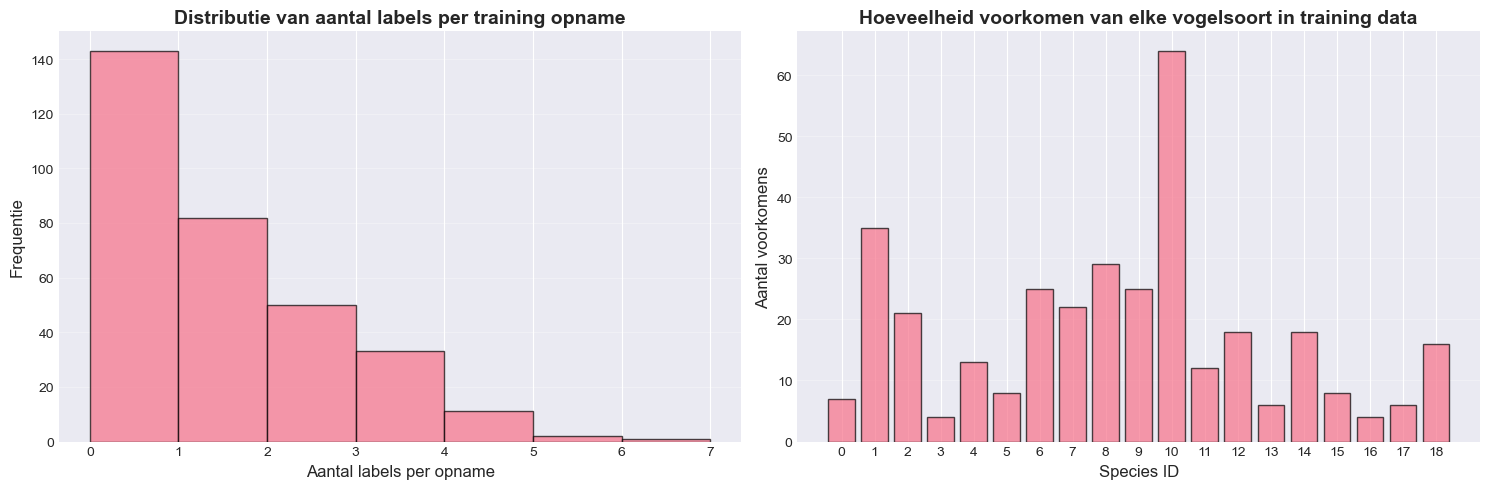


Meest voorkomende soorten:
   0 - Brown Creeper                 :   7 voorkomens
   1 - Pacific Wren                  :  35 voorkomens
   2 - Pacific-slope Flycatcher      :  21 voorkomens
   3 - Red-breasted Nuthatch         :   4 voorkomens
   4 - Dark-eyed Junco               :  13 voorkomens
   5 - Olive-sided Flycatcher        :   8 voorkomens
   6 - Hermit Thrush                 :  25 voorkomens
   7 - Chestnut-backed Chickadee     :  22 voorkomens
   8 - Varied Thrush                 :  29 voorkomens
   9 - Hermit Warbler                :  25 voorkomens


In [28]:
# Visualisatie van label distributie
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Aantal labels per opname (training data)
train_data = df[df['is_train']]
axes[0].hist(train_data['num_labels'], bins=range(8), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Aantal labels per opname', fontsize=12)
axes[0].set_ylabel('Frequentie', fontsize=12)
axes[0].set_title('Distributie van aantal labels per training opname', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Welke species komen het meest voor?
all_species = []
for labels in train_data['labels']:
    all_species.extend(labels)

species_counts = pd.Series(all_species).value_counts().sort_index()
axes[1].bar(species_counts.index, species_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Species ID', fontsize=12)
axes[1].set_ylabel('Aantal voorkomens', fontsize=12)
axes[1].set_title('Hoeveelheid voorkomen van elke vogelsoort in training data', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(19))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMeest voorkomende soorten:")
for species_id, count in species_counts.head(10).items():
    species_name = species_df[species_df['class_id'] == species_id]['species'].values[0]
    print(f"  {species_id:2d} - {species_name:30s}: {count:3d} voorkomens")

## Stap 5: Audio Data Exploratie

Laten we een audio bestand laden en bekijken wat de eigenschappen zijn.

In [30]:
# Haal een training sample met labels
sample_rec = train_data[train_data['num_labels'] > 0].iloc[0]
print(f"Voorbeeld Recording Info:")
print(f"Recording ID: {sample_rec['rec_id']}")
print(f"Labels: {sample_rec['labels']}")
print(f"Species namen:")
for label in sample_rec['labels']:
    species_name = species_df[species_df['class_id'] == label]['species'].values[0]
    print(f"  - {label}: {species_name}")

# Vind het bijbehorende WAV bestand
rec_id_mapping = pd.read_csv(REC_ID_TO_FILE)
wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == sample_rec['rec_id']]['filename'].values[0]
wav_path = SRC_WAVS / f"{wav_filename}.wav"  # Voeg .wav extensie toe

print(f"\nWAV bestand: {wav_filename}.wav")
print(f"Pad: {wav_path}")
print(f"Bestaat: {wav_path.exists()}")

# Laad het audio bestand
if wav_path.exists():
    audio, sr = librosa.load(wav_path, sr=None)
    duration = len(audio) / sr
    
    print(f"\n🎵 Audio eigenschappen:")
    print(f"Sample rate: {sr} Hz")
    print(f"Duur: {duration:.2f} seconden")
    print(f"Aantal samples: {len(audio)}")
    print(f"Audio shape: {audio.shape}")

Voorbeeld Recording Info:
Recording ID: 2
Labels: [11, 12]
Species namen:
  - 11: Hammond's Flycatcher
  - 12: Western Tanager

WAV bestand: PC1_20090606_050012_0010.wav
Pad: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data\src_wavs\PC1_20090606_050012_0010.wav
Bestaat: True

🎵 Audio eigenschappen:
Sample rate: 16000 Hz
Duur: 10.00 seconden
Aantal samples: 160000
Audio shape: (160000,)


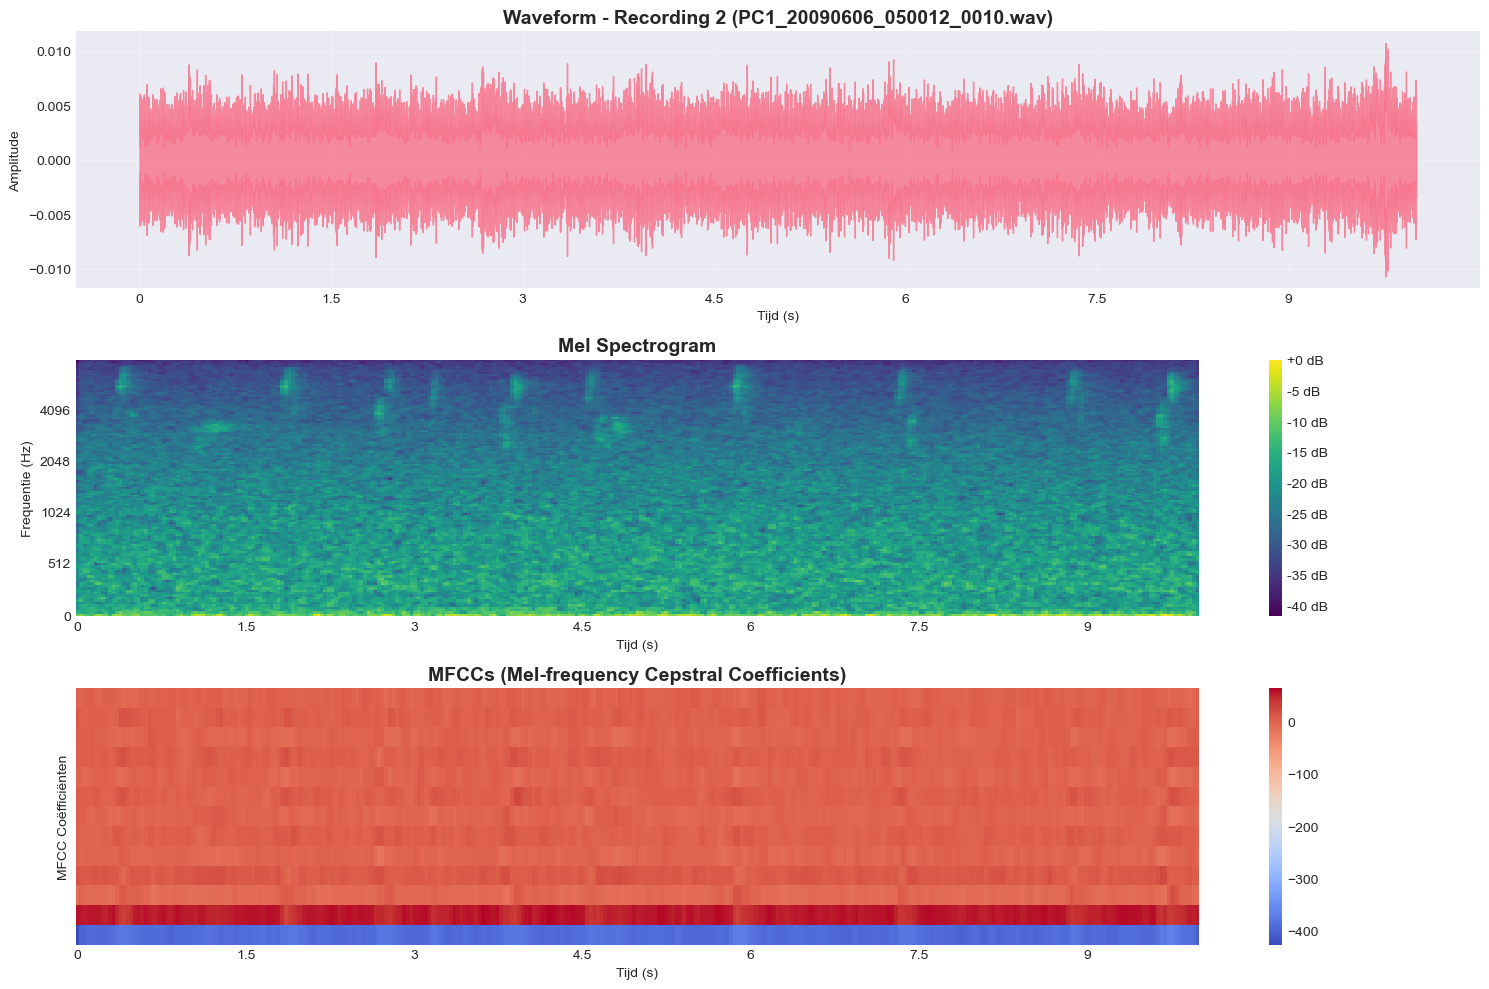


Feature dimensies:
Mel Spectrogram shape: (128, 313)
MFCCs shape: (13, 313)


In [32]:
# Visualisatie van audio sample
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1. Waveform
librosa.display.waveshow(audio, sr=sr, ax=axes[0], alpha=0.8)
axes[0].set_title(f'Waveform - Recording {sample_rec["rec_id"]} ({wav_filename}.wav)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tijd (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# 2. Spectrogram (Mel)
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                ax=axes[1], fmax=8000, cmap='viridis')
axes[1].set_title('Mel Spectrogram', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tijd (s)')
axes[1].set_ylabel('Frequentie (Hz)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

# 3. MFCC (Mel-frequency cepstral coefficients)
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
img2 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[2], cmap='coolwarm')
axes[2].set_title('MFCCs (Mel-frequency Cepstral Coefficients)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tijd (s)')
axes[2].set_ylabel('MFCC Coëfficiënten')
fig.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\nFeature dimensies:")
print(f"Mel Spectrogram shape: {mel_spec.shape}")
print(f"MFCCs shape: {mfccs.shape}")

Nu hebben we inzicht in de data. We gaan nu de data pre processen om het klaar te stomen voor het NN

PRE PROCESSING 1: Windruis verwijderen

De audio bestanden hebben heel veel wind geluid die te horen is. Dit is ruis waar we liever het NN niet op willen trainen. Deze gaan we hieronder verwijderen

In [59]:
# Importeer extra libraries voor noise reduction
from scipy.fft import fft
from scipy import signal

print("Extra libraries voor noise reduction geladen!")

Extra libraries voor noise reduction geladen!


### Stap 1: Functies voor Spectral Analysis

We gaan eerst een functie maken om het spectrogram te berekenen met de gegeven parameters.

In [66]:
Gebruikte_Step = 4
Gebruikte_K = 512
Gebruikte_N = 160000

def create_spectrogram(audio_signal, N=Gebruikte_N, K=Gebruikte_K, Step=Gebruikte_Step):
    
    ##Maakt een spectrogram van een audio signaal met windowing
    
    ##Parameters:
    ##- audio_signal: Het audio signaal (numpy array)
    ##- N: Totaal aantal samples (default: 160000 = 10 sec @ 16kHz)
    ##- K: FFT venster grootte (512 samples)
    ##- Step: Hop size factor (overlapping van vensters)

    #Returns:
    #- Spectrogram als numpy array

    # Hamming window om spectral leakage te verminderen
    window = 0.5 * (1 - np.cos(np.array(range(K)) * 2 * np.pi / (K - 1)))
    
    Spectrogram = []
    
    # Bereken aantal frames
    num_frames = int(Step * len(audio_signal) / K) - Step
    
    for j in range(num_frames):
        # Extract een frame uit het signaal
        start_idx = j * K // Step
        end_idx = (j + Step) * K // Step
        
        if end_idx <= len(audio_signal):
            vec = audio_signal[start_idx:end_idx] * window
            
            # FFT en neem alleen de positieve frequenties
            fft_result = fft(vec, K)[:K // 2]
            Spectrogram.append(np.abs(fft_result))
    
    return np.array(Spectrogram).T  # Transpose voor (freq, time) formaat

print("Spectrogram functie gedefinieerd!")
print("Gebruikte K=", Gebruikte_K)
print("Step=", Gebruikte_Step, ": Overlap factor voor betere tijdsresolutie")
print("Hamming window: Reduceert spectral leakage")

Spectrogram functie gedefinieerd!
Gebruikte K= 512
Step= 4 : Overlap factor voor betere tijdsresolutie
Hamming window: Reduceert spectral leakage


### Stap 2: Noise Reduction met Spectral Subtraction

We gebruiken spectral subtraction: schat het ruis-profiel en trek dit af van het signaal.

In [67]:
# THRESHOLDS - Pas deze aan voor noise reduction
NOISE_FRAMES = 20   # Aantal stilste frames voor ruis schatting
ALPHA = 2.0         # Over-subtraction factor (hoger = meer ruis weg)
BETA = 0.1          # Spectral floor (minimale energie na cleaning)

def reduce_noise_spectral_subtraction(audio_signal, sr=16000):
    """
    Vermindert ruis door spectral subtraction
    """
    # Maak spectrogram
    spec = create_spectrogram(audio_signal)
    
    # Vind de stilste frames (waarschijnlijk alleen ruis)
    frame_energies = np.sum(spec, axis=0)
    noise_frame_indices = np.argsort(frame_energies)[:NOISE_FRAMES]
    
    # Schat het ruis-profiel (gemiddelde van stilste frames)
    noise_profile = np.mean(spec[:, noise_frame_indices], axis=1, keepdims=True)
    
    # Trek ruis af
    cleaned_spec = spec - ALPHA * noise_profile
    
    # Zet negatieve waarden op een minimum niveau (spectral floor)
    cleaned_spec = np.maximum(cleaned_spec, BETA * spec)
    
    return cleaned_spec, noise_profile

print("Noise reduction functie gedefinieerd!")
print(f"   - Noise frames: {NOISE_FRAMES}")
print(f"   - Alpha: {ALPHA} (over-subtraction)")
print(f"   - Beta: {BETA} (spectral floor)")

Noise reduction functie gedefinieerd!
   - Noise frames: 20
   - Alpha: 2.0 (over-subtraction)
   - Beta: 0.1 (spectral floor)


### Stap 3: Test noise reduction op voorbeeld audio

In [68]:
# Test op het eerder geladen audio bestand
print(f"Test noise reduction op Recording {sample_rec['rec_id']}")
print(f"Labels: {sample_rec['labels']}")

# Apply noise reduction
cleaned_spec, noise_profile = reduce_noise_spectral_subtraction(audio, sr)
original_spec = create_spectrogram(audio)

print(f"\nNoise reduction toegepast!")
print(f"Original spectrogram shape: {original_spec.shape}")
print(f"Cleaned spectrogram shape: {cleaned_spec.shape}")

Test noise reduction op Recording 2
Labels: [11, 12]

Noise reduction toegepast!
Original spectrogram shape: (256, 1246)
Cleaned spectrogram shape: (256, 1246)


### Stap 4: Visualisatie Voor vs Na

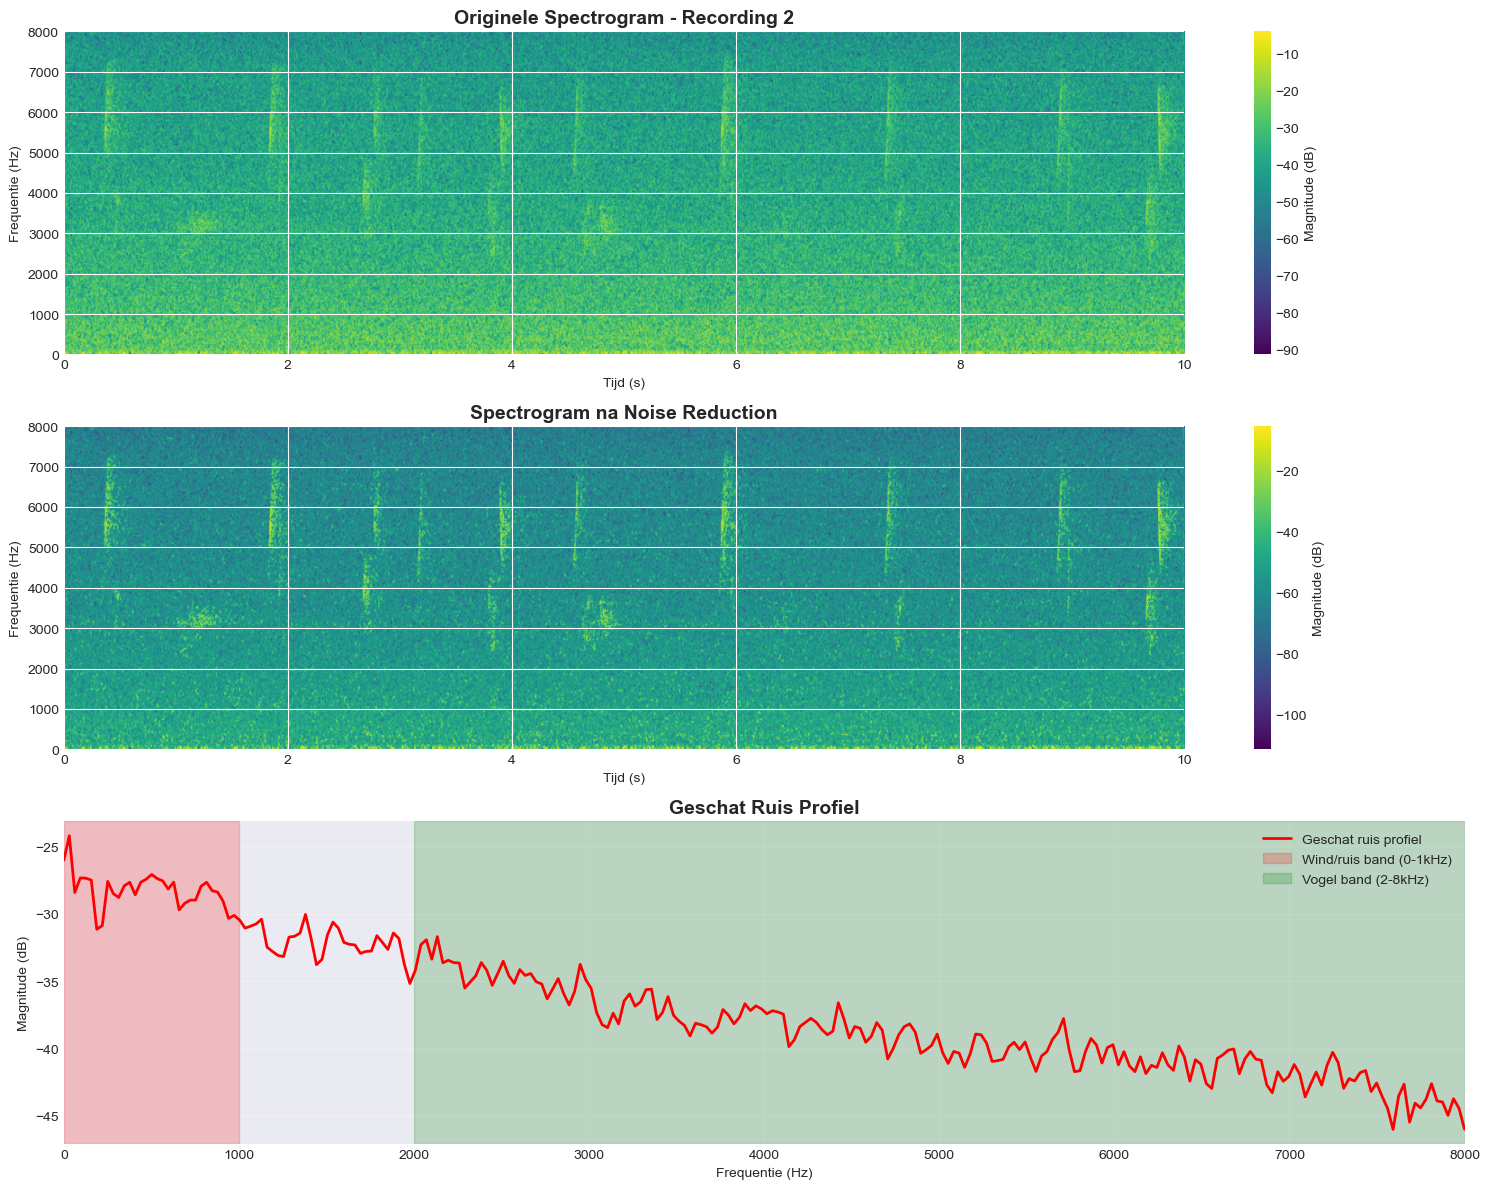


Interpretatie:
- Origineel: Zie veel laag-frequente energie (ruis)
- Na cleaning: Vogel geluiden steken duidelijker uit
- Ruis profiel: Toont welke frequenties als ruis worden beschouwd


In [69]:
# Visualisatie: Origineel vs Cleaned
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Parameters voor visualisatie
K = 512
sr = 16000
freqs = np.linspace(0, sr/2, K//2)
times_spec = np.linspace(0, len(audio)/sr, original_spec.shape[1])

# 1. Originele Spectrogram
im1 = axes[0].imshow(20*np.log10(original_spec + 1e-10), 
                      aspect='auto', origin='lower', cmap='viridis',
                      extent=[0, len(audio)/sr, 0, sr/2])
axes[0].set_title(f'Originele Spectrogram - Recording {sample_rec["rec_id"]}', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tijd (s)')
axes[0].set_ylabel('Frequentie (Hz)')
axes[0].set_ylim([0, 8000])  # Focus op vogel-frequenties
fig.colorbar(im1, ax=axes[0], label='Magnitude (dB)')

# 2. Geschoonde Spectrogram
im2 = axes[1].imshow(20*np.log10(cleaned_spec + 1e-10), 
                      aspect='auto', origin='lower', cmap='viridis',
                      extent=[0, len(audio)/sr, 0, sr/2])
axes[1].set_title('Spectrogram na Noise Reduction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tijd (s)')
axes[1].set_ylabel('Frequentie (Hz)')
axes[1].set_ylim([0, 8000])
fig.colorbar(im2, ax=axes[1], label='Magnitude (dB)')

# 3. Ruis profiel
axes[2].plot(freqs, 20*np.log10(noise_profile.flatten() + 1e-10), 
             linewidth=2, color='red', label='Geschat ruis profiel')
axes[2].axvspan(0, 1000, alpha=0.2, color='red', label='Wind/ruis band (0-1kHz)')
axes[2].axvspan(2000, 8000, alpha=0.2, color='green', label='Vogel band (2-8kHz)')
axes[2].set_title('Geschat Ruis Profiel', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequentie (Hz)')
axes[2].set_ylabel('Magnitude (dB)')
axes[2].set_xlim([0, 8000])
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nInterpretatie:")
print("- Origineel: Zie veel laag-frequente energie (ruis)")
print("- Na cleaning: Vogel geluiden steken duidelijker uit")
print("- Ruis profiel: Toont welke frequenties als ruis worden beschouwd")

In [71]:
# Maak output directory
OUTPUT_DIR = BASE_DIR / "Spectogram_DeNoise"
OUTPUT_DIR.mkdir(exist_ok=True)

def process_and_save_all_spectrograms(df, rec_id_mapping, src_wavs_path, output_path, sr=16000):
    """
    Verwerk alle audio bestanden: pas noise reduction toe en sla spectrograms op als BMP
    """
    print(f"Processing {len(df)} audio files...")
    print(f"Output directory: {output_path}\n")
    
    success_count = 0
    error_count = 0
    
    for idx, row in df.iterrows():
        rec_id = row['rec_id']
        
        # Vind WAV bestand
        wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
        wav_path = src_wavs_path / f"{wav_filename}.wav"
        
        if not wav_path.exists():
            print(f"WARNING: {wav_path} niet gevonden!")
            error_count += 1
            continue
        
        try:
            # Laad audio
            audio_signal, _ = librosa.load(wav_path, sr=sr)
            
            # Apply noise reduction
            cleaned_spec, noise_prof = reduce_noise_spectral_subtraction(audio_signal, sr)
            
            # Converteer spectrogram naar 8-bit image (0-255)
            # Normaliseer naar dB schaal
            spec_db = 20 * np.log10(cleaned_spec + 1e-10)
            spec_db = spec_db - np.min(spec_db)  # Start bij 0
            spec_db = spec_db / np.max(spec_db) * 255  # Schaal naar 0-255
            spec_img = spec_db.astype(np.uint8)
            
            # Sla op als BMP
            output_file = output_path / f"{wav_filename}_cleaned.bmp"
            plt.imsave(output_file, spec_img, cmap='gray', format='bmp')
            
            success_count += 1
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(df)} files... ({success_count} success, {error_count} errors)")
                
        except Exception as e:
            print(f"ERROR processing {wav_filename}: {e}")
            error_count += 1
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"  Success: {success_count}/{len(df)}")
    print(f"  Errors: {error_count}/{len(df)}")
    print(f"  Saved to: {output_path}")
    
    return success_count, error_count

# Run processing
print("Starting batch processing met noise reduction...")
print("Dit kan een paar minuten duren...\n")

success, errors = process_and_save_all_spectrograms(df, rec_id_mapping, SRC_WAVS, OUTPUT_DIR)

print(f"\nKlaar! Je kunt de schone spectrograms vinden in: {OUTPUT_DIR}")

Starting batch processing met noise reduction...
Dit kan een paar minuten duren...

Processing 645 audio files...
Output directory: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_DeNoise

  Processed 50/645 files... (50 success, 0 errors)
  Processed 50/645 files... (50 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 350/645 files... (350 success, 0 errors)
  Processed 350/645 files... (350 success, 0 errors)
  Processed 400/645 files... (400 success, 0 errors)

In [75]:
# THRESHOLDS - Pas deze aan voor vogel segmentatie
INTENSITY_THRESHOLD_PERCENTILE = 90  # Percentile voor intensity threshold (hoger = alleen sterkste signalen)
MIN_DURATION_FRAMES = 1             # Minimale duur van een vogel signaal in frames
MEDIAN_FILTER_SIZE = 3               # Grootte van median filter voor ruis verwijdering

# Maak output directory
OUTPUT_BIRD_ONLY = BASE_DIR / "Spectogram_Only_Bird_Noises"
OUTPUT_BIRD_ONLY.mkdir(exist_ok=True)

def isolate_bird_sounds(cleaned_spec):
    """
    Isoleer alleen de vogel geluiden uit een spectrogram door adaptive thresholding
    """
    # Converteer naar dB
    spec_db = 20 * np.log10(cleaned_spec + 1e-10)
    
    # Bereken adaptive threshold per frequentie bin
    threshold = np.percentile(spec_db, INTENSITY_THRESHOLD_PERCENTILE, axis=1, keepdims=True)
    
    # Maak binaire mask: alleen waarden boven threshold
    bird_mask = spec_db > threshold
    
    # Apply median filter om kleine ruis punten te verwijderen
    from scipy.ndimage import median_filter
    bird_mask = median_filter(bird_mask.astype(float), size=(MEDIAN_FILTER_SIZE, MEDIAN_FILTER_SIZE))
    bird_mask = bird_mask > 0.5
    
    # Verwijder korte events (temporal filtering)
    for freq_idx in range(bird_mask.shape[0]):
        # Tel opeenvolgende True waarden
        counts = []
        count = 0
        for time_idx in range(bird_mask.shape[1]):
            if bird_mask[freq_idx, time_idx]:
                count += 1
            else:
                if count > 0:
                    counts.append((time_idx - count, count))
                count = 0
        if count > 0:
            counts.append((bird_mask.shape[1] - count, count))
        
        # Verwijder korte segmenten
        for start, duration in counts:
            if duration < MIN_DURATION_FRAMES:
                bird_mask[freq_idx, start:start+duration] = False
    
    # Apply mask: alleen vogel geluiden behouden, rest = 0
    bird_only_spec = np.where(bird_mask, cleaned_spec, 0)
    
    return bird_only_spec, bird_mask

def process_and_save_bird_only_spectrograms(df, rec_id_mapping, src_wavs_path, output_path, sr=16000):
    """
    Verwerk alle audio: noise reduction + vogel isolatie, sla op als BMP
    """
    print(f"Processing {len(df)} audio files voor bird-only segmentatie...")
    print(f"Output directory: {output_path}\n")
    print(f"Thresholds:")
    print(f"  - Intensity percentile: {INTENSITY_THRESHOLD_PERCENTILE}")
    print(f"  - Min duration: {MIN_DURATION_FRAMES} frames")
    print(f"  - Median filter: {MEDIAN_FILTER_SIZE}x{MEDIAN_FILTER_SIZE}\n")
    
    success_count = 0
    error_count = 0
    
    for idx, row in df.iterrows():
        rec_id = row['rec_id']
        
        # Vind WAV bestand
        wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
        wav_path = src_wavs_path / f"{wav_filename}.wav"
        
        if not wav_path.exists():
            print(f"WARNING: {wav_path} niet gevonden!")
            error_count += 1
            continue
        
        try:
            # Laad audio
            audio_signal, _ = librosa.load(wav_path, sr=sr)
            
            # Apply noise reduction
            cleaned_spec, _ = reduce_noise_spectral_subtraction(audio_signal, sr)
            
            # Isoleer vogel geluiden
            bird_only_spec, bird_mask = isolate_bird_sounds(cleaned_spec)
            
            # Converteer naar 8-bit image (0-255)
            spec_db = 20 * np.log10(bird_only_spec + 1e-10)
            
            # Alleen normaliseren waar er bird signals zijn
            if np.any(bird_mask):
                bird_values = spec_db[bird_mask]
                min_val = np.min(bird_values)
                max_val = np.max(bird_values)
                
                # Normaliseer alleen de vogel geluiden
                spec_normalized = np.zeros_like(spec_db)
                spec_normalized[bird_mask] = (bird_values - min_val) / (max_val - min_val + 1e-10) * 255
            else:
                spec_normalized = np.zeros_like(spec_db)
            
            spec_img = spec_normalized.astype(np.uint8)
            
            # Sla op als BMP
            output_file = output_path / f"{wav_filename}_bird_only.bmp"
            plt.imsave(output_file, spec_img, cmap='gray', format='bmp')
            
            success_count += 1
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(df)} files... ({success_count} success, {error_count} errors)")
                
        except Exception as e:
            print(f"ERROR processing {wav_filename}: {e}")
            error_count += 1
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"  Success: {success_count}/{len(df)}")
    print(f"  Errors: {error_count}/{len(df)}")
    print(f"  Saved to: {output_path}")
    
    return success_count, error_count

# Run processing
print("Starting bird-only segmentatie...")
print("Dit kan een paar minuten duren...\n")

success_bird, errors_bird = process_and_save_bird_only_spectrograms(df, rec_id_mapping, SRC_WAVS, OUTPUT_BIRD_ONLY)

print(f"\nKlaar! Bird-only spectrograms in: {OUTPUT_BIRD_ONLY}")

Starting bird-only segmentatie...
Dit kan een paar minuten duren...

Processing 645 audio files voor bird-only segmentatie...
Output directory: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_Only_Bird_Noises

Thresholds:
  - Intensity percentile: 90
  - Min duration: 1 frames
  - Median filter: 3x3

  Processed 50/645 files... (50 success, 0 errors)
  Processed 50/645 files... (50 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 350/645 files... (350 success, 0 